In [ ]:
# Step 1: Data Collection and Exploration
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


# Load the training dataset
df = pd.read_csv("train_u6lujuX_CVtuZ9i.csv")

# First look at the data
print("Shape:", df.shape)
df.head()

Shape: (614, 13)


,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [3]:
# Data types and non-null counts
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    str    
 1   Gender             601 non-null    str    
 2   Married            611 non-null    str    
 3   Dependents         599 non-null    str    
 4   Education          614 non-null    str    
 5   Self_Employed      582 non-null    str    
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         592 non-null    float64
 9   Loan_Amount_Term   600 non-null    float64
 10  Credit_History     564 non-null    float64
 11  Property_Area      614 non-null    str    
 12  Loan_Status        614 non-null    str    
dtypes: float64(4), int64(1), str(8)
memory usage: 83.4 KB


In [4]:
# Statistical summary of numeric columns
df.describe()


,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History
count,614.000000,614.000000,592.000000,600.00000,564.000000
mean,5403.459283,1621.245798,146.412162,342.00000,0.842199
std,6109.041673,2926.248369,85.587325,65.12041,0.364878
min,150.000000,0.000000,9.000000,12.00000,0.000000
25%,2877.500000,0.000000,100.000000,360.00000,1.000000
50%,3812.500000,1188.500000,128.000000,360.00000,1.000000
75%,5795.000000,2297.250000,168.000000,360.00000,1.000000
max,81000.000000,41667.000000,700.000000,480.00000,1.000000


In [5]:
# Check missing values in each column
df.isnull().sum()


Loan_ID               0
Gender               13
Married               3
Dependents           15
Education             0
Self_Employed        32
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           22
Loan_Amount_Term     14
Credit_History       50
Property_Area         0
Loan_Status           0
dtype: int64

In [6]:
# Check the target variable balance (Y = approved, N = rejected)
df["Loan_Status"].value_counts()


Loan_Status
Y    422
N    192
Name: count, dtype: int64

In [7]:
# Step 2: Data Cleaning and Transformation

# 2.1 Check for duplicate rows
print("Duplicate rows:", df.duplicated().sum())
df = df.drop_duplicates()


Duplicate rows: 0


In [8]:
# 2.2 Handle missing values
# Fill categorical columns with mode (most frequent value)
cat_cols = ["Gender", "Married", "Dependents", "Self_Employed", "Credit_History"]
for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

# Fill numeric columns with median (robust to outliers)
num_cols = ["LoanAmount", "Loan_Amount_Term"]
for col in num_cols:
    df[col] = df[col].fillna(df[col].median())


In [9]:
# 2.3 Verify cleaning worked
print(df.isnull().sum())
print("Shape after cleaning:", df.shape)


Loan_ID              0
Gender               0
Married              0
Dependents           0
Education            0
Self_Employed        0
ApplicantIncome      0
CoapplicantIncome    0
LoanAmount           0
Loan_Amount_Term     0
Credit_History       0
Property_Area        0
Loan_Status          0
dtype: int64
Shape after cleaning: (614, 13)


In [10]:
# Step 3: Encoding categorical variables

# 3.1 Binary (Yes/No) columns -> 1/0
df["Gender"] = df["Gender"].map({"Male": 1, "Female": 0})
df["Married"] = df["Married"].map({"Yes": 1, "No": 0})
df["Education"] = df["Education"].map({"Graduate": 1, "Not Graduate": 0})
df["Self_Employed"] = df["Self_Employed"].map({"Yes": 1, "No": 0})

# Target column -> 1/0  (1 = loan approved, 0 = rejected)
df["Loan_Status"] = df["Loan_Status"].map({"Y": 1, "N": 0})


In [11]:
# 3.2 Dependents: "3+" -> 3, then make it numeric
df["Dependents"] = df["Dependents"].replace("3+", 3).astype(int)

# 3.3 Credit_History is 1.0/0.0 float -> clean int
df["Credit_History"] = df["Credit_History"].astype(int)


In [12]:
# 3.4 Property_Area has 3 categories with no natural order (Rural/Semiurban/Urban),
# so we use one-hot encoding instead of 1/0 mapping
df = pd.get_dummies(df, columns=["Property_Area"], drop_first=True)

# 3.5 Drop Loan_ID — it's just an identifier, it can't predict anything
df = df.drop(columns=["Loan_ID"])


In [13]:
# 3.6 Verify: every column should now be numeric
print(df.dtypes)
print("Shape:", df.shape)
df.head()


Gender                       int64
Married                      int64
Dependents                   int64
Education                    int64
Self_Employed                int64
ApplicantIncome              int64
CoapplicantIncome          float64
LoanAmount                 float64
Loan_Amount_Term           float64
Credit_History               int64
Loan_Status                  int64
Property_Area_Semiurban       bool
Property_Area_Urban           bool
dtype: object
Shape: (614, 13)


,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Loan_Status,Property_Area_Semiurban,Property_Area_Urban
0,1,0,0,1,0,5849,0.0,128.0,360.0,1,1,False,True
1,1,1,1,1,0,4583,1508.0,128.0,360.0,1,0,False,False
2,1,1,0,1,1,3000,0.0,66.0,360.0,1,1,False,True
3,1,1,0,0,0,2583,2358.0,120.0,360.0,1,1,False,True
4,1,0,0,1,0,6000,0.0,141.0,360.0,1,1,False,True


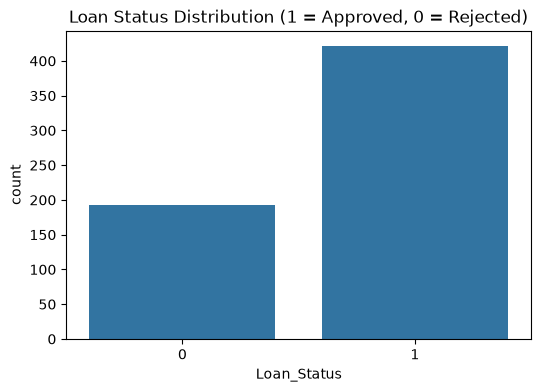

Loan_Status
1    0.687
0    0.313
Name: proportion, dtype: float64


In [14]:
# Step 4: Exploratory Data Analysis (EDA)

# 4.1 Target distribution — is the data balanced?
plt.figure(figsize=(6, 4))
sns.countplot(x="Loan_Status", data=df)
plt.title("Loan Status Distribution (1 = Approved, 0 = Rejected)")
plt.xlabel("Loan_Status")
plt.show()

print(df["Loan_Status"].value_counts(normalize=True).round(3))


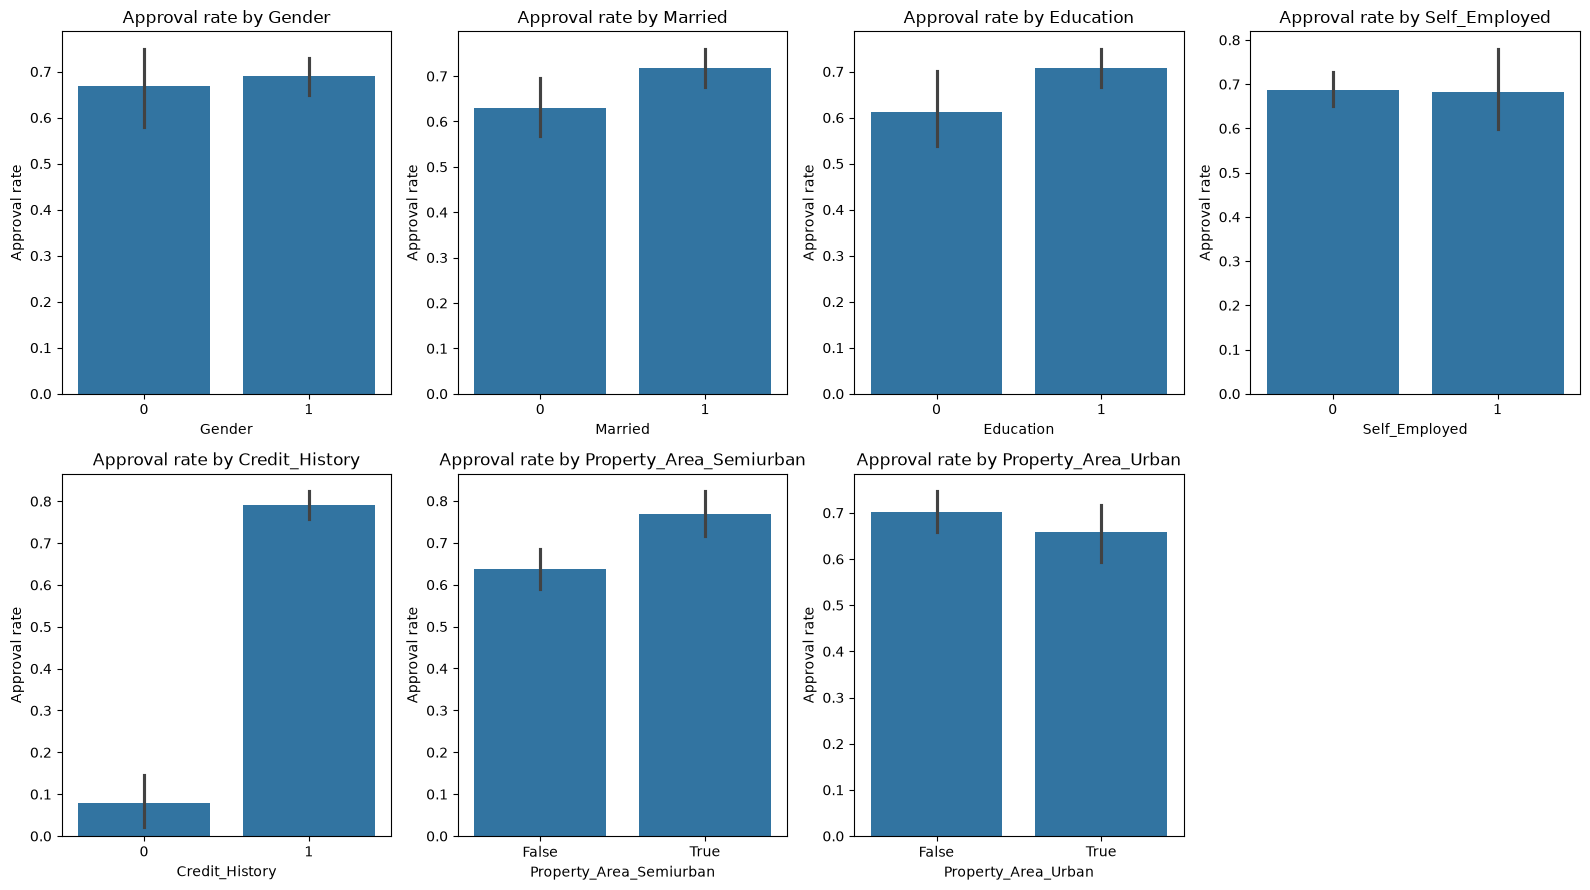

In [15]:
# 4.2 Approval rate for each categorical feature
cat_features = ["Gender", "Married", "Education", "Self_Employed",
                "Credit_History", "Property_Area_Semiurban", "Property_Area_Urban"]

fig, axes = plt.subplots(2, 4, figsize=(16, 9))
axes = axes.flatten()
for i, col in enumerate(cat_features):
    sns.barplot(x=col, y="Loan_Status", data=df, ax=axes[i])
    axes[i].set_title(f"Approval rate by {col}")
    axes[i].set_ylabel("Approval rate")
fig.delaxes(axes[7])  # remove the empty 8th slot
plt.tight_layout()
plt.show()


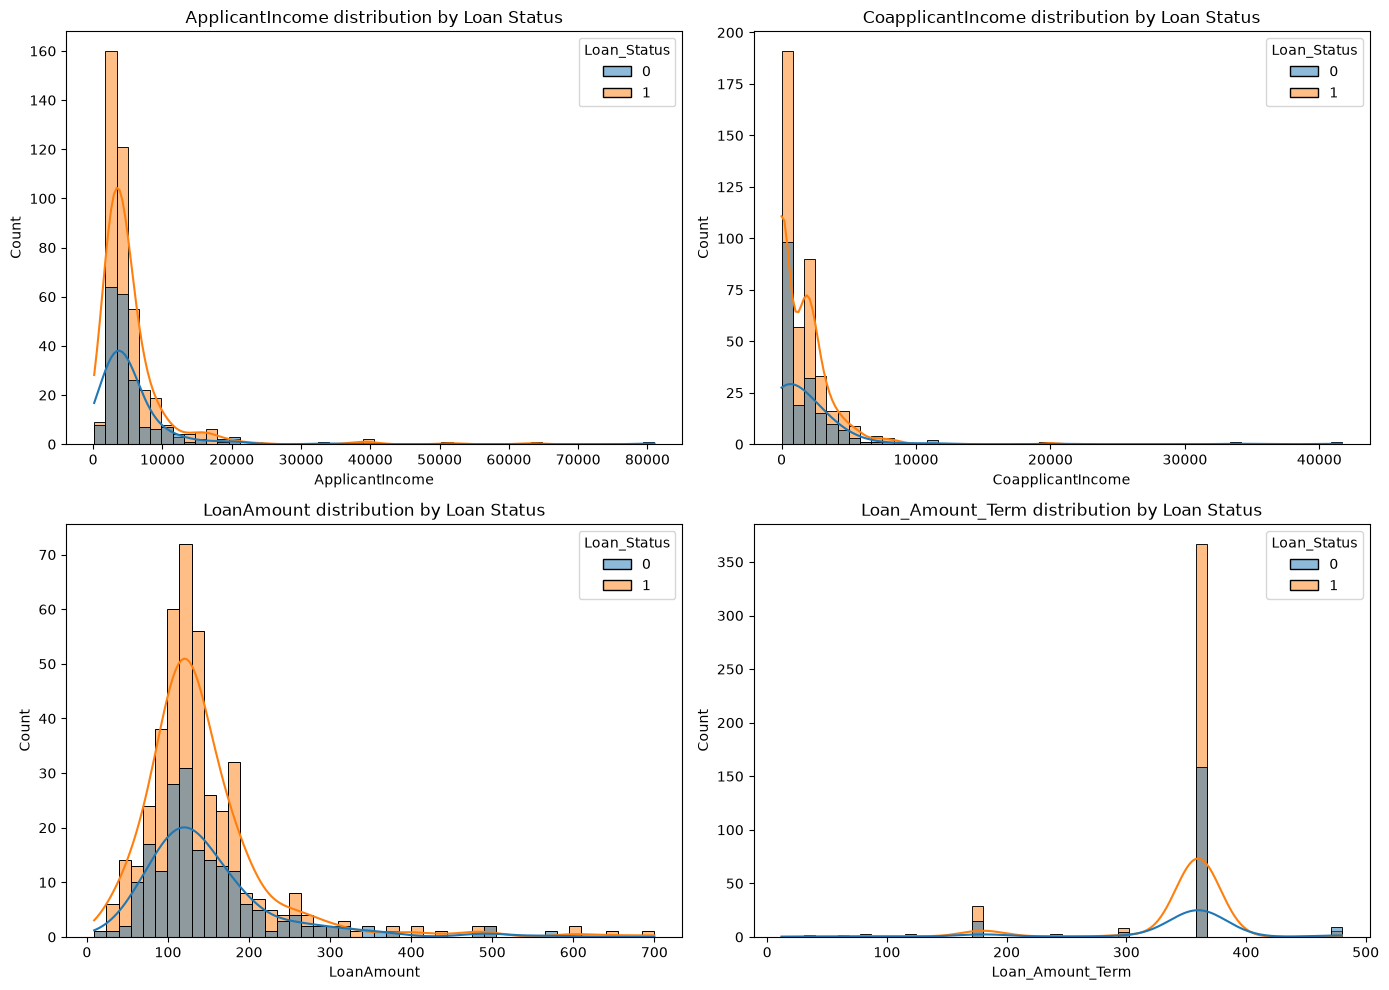

In [16]:
# 4.3 Numeric feature distributions split by loan status
num_features = ["ApplicantIncome", "CoapplicantIncome", "LoanAmount", "Loan_Amount_Term"]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()
for i, col in enumerate(num_features):
    sns.histplot(data=df, x=col, hue="Loan_Status", kde=True, ax=axes[i])
    axes[i].set_title(f"{col} distribution by Loan Status")
plt.tight_layout()
plt.show()


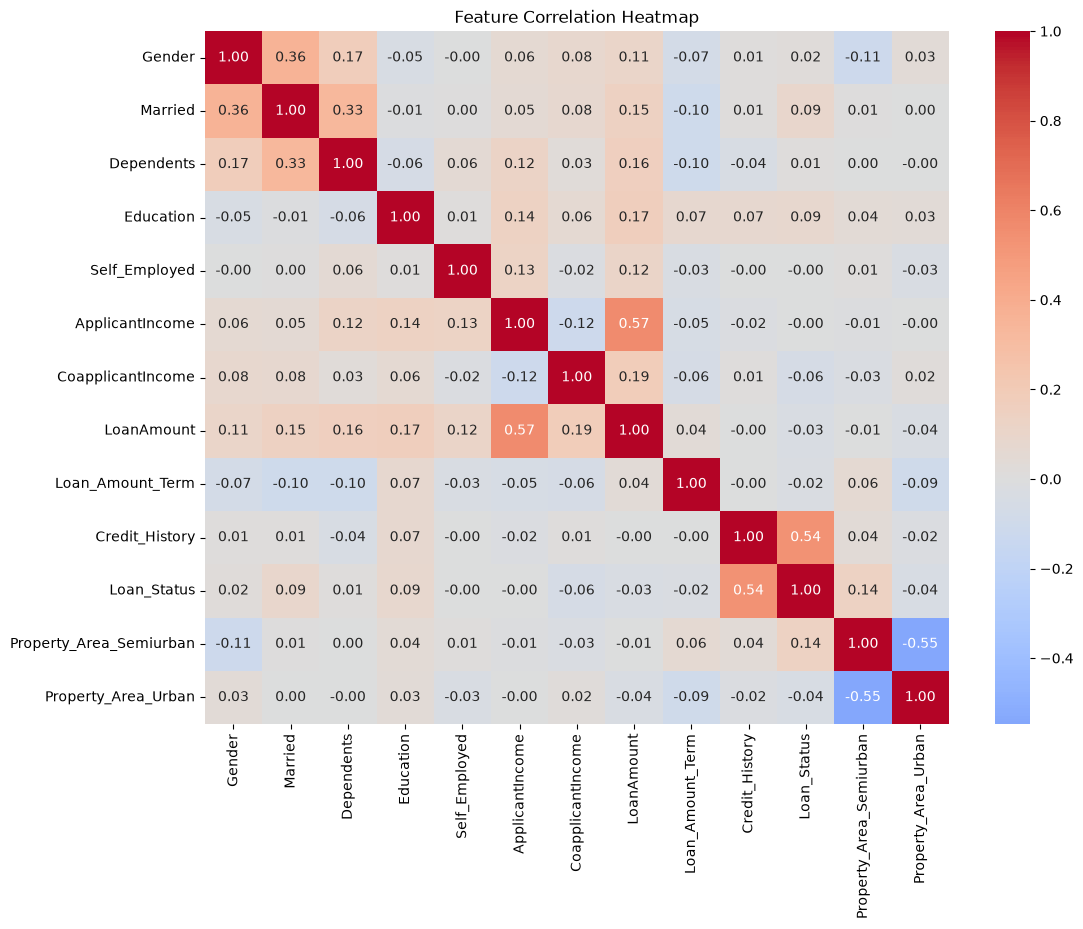

In [17]:
# 4.4 Correlation heatmap — relationships between all variables
plt.figure(figsize=(12, 9))
sns.heatmap(df.corr(numeric_only=True), annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Feature Correlation Heatmap")
plt.show()


# key findings from your EDA

1) 68% loan was approved and 31% was rejected from the number of applicant applied.
2) Applicants with Credit_History = 1 get approved at a much higher rate.
3) There is no relationship between loan status and categorical featurs.
4) credit history and loan status has +ve correlation by 0.54 and aaplicant income and loan amount has also +ve correlation by 0.57.

In [18]:
# Step 5: Feature Selection and Engineering

# 5.1 Feature engineering: combine the two income columns
df["Total_Income"] = df["ApplicantIncome"] + df["CoapplicantIncome"]


In [19]:
# 5.2 Check how strongly each feature correlates with the target
corr_with_target = df.corr(numeric_only=True)["Loan_Status"].sort_values(ascending=False)
print(corr_with_target)


Loan_Status                1.000000
Credit_History             0.540556
Property_Area_Semiurban    0.136540
Married                    0.091478
Education                  0.085884
Gender                     0.017987
Dependents                 0.010118
Self_Employed             -0.003700
ApplicantIncome           -0.004710
Loan_Amount_Term          -0.022549
Total_Income              -0.031271
LoanAmount                -0.033214
Property_Area_Urban       -0.043621
CoapplicantIncome         -0.059187
Name: Loan_Status, dtype: float64


In [20]:
# 5.3 Feature selection: drop redundant features
# ApplicantIncome and CoapplicantIncome are now fully captured inside Total_Income,
# so keeping all three would be redundant — we keep only Total_Income
df = df.drop(columns=["ApplicantIncome", "CoapplicantIncome"])

print("Final shape:", df.shape)
print("Final columns:", df.columns.tolist())


Final shape: (614, 12)
Final columns: ['Gender', 'Married', 'Dependents', 'Education', 'Self_Employed', 'LoanAmount', 'Loan_Amount_Term', 'Credit_History', 'Loan_Status', 'Property_Area_Semiurban', 'Property_Area_Urban', 'Total_Income']


In [21]:
# Step 6: Model Development

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# 6.1 Separate features (X) and target (y)
X = df.drop(columns=["Loan_Status"])
y = df["Loan_Status"]

# 6.2 Train-test split — stratify keeps the approved/rejected ratio the same in both sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print("Train shape:", X_train.shape, " Test shape:", X_test.shape)


Train shape: (491, 11)  Test shape: (123, 11)


In [22]:
# 6.3 Train three different algorithms and compare
models = {
    # Scaling helps Logistic Regression because features are on very different scales
    # (income in thousands vs 0/1 flags)
    "Logistic Regression": make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000)),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
}

for name, model in models.items():
    model.fit(X_train, y_train)
    train_acc = accuracy_score(y_train, model.predict(X_train))
    test_acc = accuracy_score(y_test, model.predict(X_test))
    print(f"{name}: train accuracy = {train_acc:.4f} | test accuracy = {test_acc:.4f}")


Logistic Regression: train accuracy = 0.7984 | test accuracy = 0.8537
Decision Tree: train accuracy = 1.0000 | test accuracy = 0.6992
Random Forest: train accuracy = 1.0000 | test accuracy = 0.8455


In [27]:
# Step 7 : Model Evaluation and Hyperparameter Tuning — SVM version
import warnings
warnings.filterwarnings("ignore")
from sklearn.svm import SVC
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score, RocCurveDisplay
from sklearn.model_selection import GridSearchCV, cross_val_score

# 7.1 Train SVM the way you learned at the institute:
# linear kernel, probability=True (needed for ROC-AUC), random_state=42
svm_model = make_pipeline(StandardScaler(), SVC(kernel="linear", probability=True, random_state=42))
svm_model.fit(X_train, y_train)
y_pred = svm_model.predict(X_test)
y_proba = svm_model.predict_proba(X_test)[:, 1]


In [28]:
# 7.2 Detailed evaluation
print("Confusion Matrix (rows = actual, columns = predicted):")
print(confusion_matrix(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))
print("ROC-AUC:", round(roc_auc_score(y_test, y_proba), 4))


Confusion Matrix (rows = actual, columns = predicted):
[[21 17]
 [ 1 84]]

Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.55      0.70        38
           1       0.83      0.99      0.90        85

    accuracy                           0.85       123
   macro avg       0.89      0.77      0.80       123
weighted avg       0.87      0.85      0.84       123

ROC-AUC: 0.7988


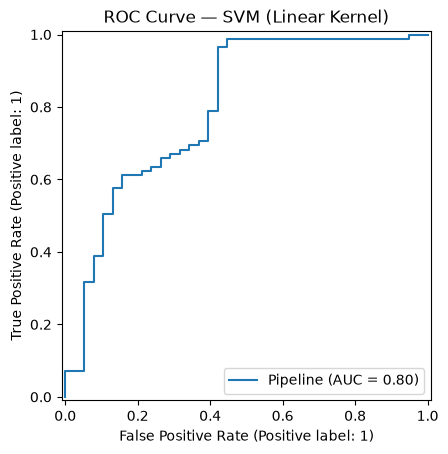

In [29]:
# 7.3 ROC curve
RocCurveDisplay.from_estimator(svm_model, X_test, y_test)
plt.title("ROC Curve — SVM (Linear Kernel)")
plt.show()


In [30]:
# 7.4 Hyperparameter tuning: try different C values with 5-fold cross-validation
# (C controls the trade-off — small C = wider margin, simpler model)
param_grid = {"svc__C": [0.01, 0.1, 1, 10, 100]}
grid = GridSearchCV(svm_model, param_grid, cv=5, scoring="accuracy")
grid.fit(X_train, y_train)

print("Best C:", grid.best_params_)
print("Best cross-validation accuracy:", round(grid.best_score_, 4))
print("Tuned model test accuracy:", round(grid.score(X_test, y_test), 4))


Best C: {'svc__C': 0.01}
Best cross-validation accuracy: 0.7984
Tuned model test accuracy: 0.8537


In [31]:
# 7.5 Robustness check: cross-validate the final tuned model on the full dataset
cv_scores = cross_val_score(grid.best_estimator_, X, y, cv=5, scoring="accuracy")
print("CV scores:", np.round(cv_scores, 4))
print("Mean CV accuracy:", round(cv_scores.mean(), 4))


CV scores: [0.813  0.7805 0.7805 0.8537 0.8197]
Mean CV accuracy: 0.8095


In [32]:
# 7.6 Save the final tuned SVM — the Streamlit app in Step 8 will load this file
import joblib
final_model = grid.best_estimator_
joblib.dump(final_model, "loan_model.pkl")
print("Saved final model to loan_model.pkl")


Saved final model to loan_model.pkl
